In [ ]:
# clone YOLOv5 repository
!git clone https://github.com/ultralytics/yolov5  # clone repo
%cd yolov5

Cloning into 'yolov5'...
remote: Enumerating objects: 17075, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 17075 (delta 29), reused 30 (delta 12), pack-reused 17022 (from 1)
Receiving objects: 100% (17075/17075), 15.69 MiB | 28.39 MiB/s, done.
Resolving deltas: 100% (11723/11723), done.
/content/yolov5/yolov5


In [ ]:
# install dependencies as necessary
!pip install -qr requirements.txt  # install dependencies (ignore errors)
import torch

from IPython.display import Image, clear_output  # to display images
from utils.downloads import attempt_download  # to download models/datasets

# clear_output()
print('Setup complete. Using torch %s %s' % (torch.__version__, torch.cuda.get_device_properties(0) if torch.cuda.is_available() else 'CPU'))


Setup complete. Using torch 2.5.1+cu121 _CudaDeviceProperties(name='Tesla T4', major=7, minor=5, total_memory=15102MB, multi_processor_count=40, uuid=c3940613-d5ac-4e70-2ec5-8c886aa955a6, L2_cache_size=4MB)


In [ ]:

!pip install -q roboflow

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="cu6UuypgYmw6CPJ924vN")
project = rf.workspace("public-1tecx").project("boat-detection-bzj6m")
version = project.version(1)
dataset = version.download("yolov5")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to boat-detection-1 in yolov5pytorch:: 100%|██████████| 19106/19106 [00:04<00:00, 3869.91it/s]


In [ ]:


%pwd

'/content/yolov5/yolov5'

In [ ]:
dataset.location

'/content/yolov5/yolov5/boat-detection-1'

In [ ]:
# Navigate to YOLOv5 directory
%cd /content/yolov5

# Pull the latest changes
!git pull


/content/yolov5
Already up to date.


In [ ]:
dataset.location

'/content/yolov5/yolov5/boat-detection-1'

In [ ]:
# this is the YAML file Roboflow wrote for us that we're loading into this notebook with our data
%cat {dataset.location}/data.yaml

names:
- boat
nc: 1
roboflow:
  license: CC BY 4.0
  project: boat-detection-bzj6m
  url: https://universe.roboflow.com/public-1tecx/boat-detection-bzj6m/dataset/1
  version: 1
  workspace: public-1tecx
test: ../test/images
train: boat-detection-1/train/images
val: boat-detection-1/valid/images


In [ ]:
# define number of classes based on YAML
import yaml
with open(dataset.location + "/data.yaml", 'r') as stream:
    num_classes = str(yaml.safe_load(stream)['nc'])

In [ ]:
num_classes

'1'

In [ ]:
%cat /content/yolov5/models/yolov5l.yaml

# Ultralytics YOLOv5 🚀, AGPL-3.0 license

# Parameters
nc: 80 # number of classes
depth_multiple: 1.0 # model depth multiple
width_multiple: 1.0 # layer channel multiple
anchors:
  - [10, 13, 16, 30, 33, 23] # P3/8
  - [30, 61, 62, 45, 59, 119] # P4/16
  - [116, 90, 156, 198, 373, 326] # P5/32

# YOLOv5 v6.0 backbone
backbone:
  # [from, number, module, args]
  [
    [-1, 1, Conv, [64, 6, 2, 2]], # 0-P1/2
    [-1, 1, Conv, [128, 3, 2]], # 1-P2/4
    [-1, 3, C3, [128]],
    [-1, 1, Conv, [256, 3, 2]], # 3-P3/8
    [-1, 6, C3, [256]],
    [-1, 1, Conv, [512, 3, 2]], # 5-P4/16
    [-1, 9, C3, [512]],
    [-1, 1, Conv, [1024, 3, 2]], # 7-P5/32
    [-1, 3, C3, [1024]],
    [-1, 1, SPPF, [1024, 5]], # 9
  ]

# YOLOv5 v6.0 head
head: [
    [-1, 1, Conv, [512, 1, 1]],
    [-1, 1, nn.Upsample, [None, 2, "nearest"]],
    [[-1, 6], 1, Concat, [1]], # cat backbone P4
    [-1, 3, C3, [512, False]], # 13

    [-1, 1, Conv, [256, 1, 1]],
    [-1, 1, nn.Upsample, [None, 2, "nearest"]],
    [[-1, 4], 1

In [ ]:
#customize iPython writefile so we can write variables
from IPython.core.magic import register_line_cell_magic

@register_line_cell_magic
def writetemplate(line, cell):
    with open(line, 'w') as f:
        f.write(cell.format(**globals()))

In [ ]:
%%writetemplate /content/yolov5/models/custom_yolov5l.yaml

# parameters
nc: {num_classes}  # number of classes
depth_multiple: 0.33  # model depth multiple
width_multiple: 0.50  # layer channel multiple

# anchors
anchors:
  - [10,13, 16,30, 33,23]  # P3/8
  - [30,61, 62,45, 59,119]  # P4/16
  - [116,90, 156,198, 373,326]  # P5/32

# YOLOv5 backbone
backbone:
  # [from, number, module, args]
  [[-1, 1, Focus, [64, 3]],  # 0-P1/2
   [-1, 1, Conv, [128, 3, 2]],  # 1-P2/4
   [-1, 3, BottleneckCSP, [128]],
   [-1, 1, Conv, [256, 3, 2]],  # 3-P3/8
   [-1, 9, BottleneckCSP, [256]],
   [-1, 1, Conv, [512, 3, 2]],  # 5-P4/16
   [-1, 9, BottleneckCSP, [512]],
   [-1, 1, Conv, [1024, 3, 2]],  # 7-P5/32
   [-1, 1, SPP, [1024, [5, 9, 13]]],
   [-1, 3, BottleneckCSP, [1024, False]],  # 9
  ]

# YOLOv5 head
head:
  [[-1, 1, Conv, [512, 1, 1]],
   [-1, 1, nn.Upsample, [None, 2, 'nearest']],
   [[-1, 6], 1, Concat, [1]],  # cat backbone P4
   [-1, 3, BottleneckCSP, [512, False]],  # 13

   [-1, 1, Conv, [256, 1, 1]],
   [-1, 1, nn.Upsample, [None, 2, 'nearest']],
   [[-1, 4], 1, Concat, [1]],  # cat backbone P3
   [-1, 3, BottleneckCSP, [256, False]],  # 17 (P3/8-small)

   [-1, 1, Conv, [256, 3, 2]],
   [[-1, 14], 1, Concat, [1]],  # cat head P4
   [-1, 3, BottleneckCSP, [512, False]],  # 20 (P4/16-medium)

   [-1, 1, Conv, [512, 3, 2]],
   [[-1, 10], 1, Concat, [1]],  # cat head P5
   [-1, 3, BottleneckCSP, [1024, False]],  # 23 (P5/32-large)

   [[17, 20, 23], 1, Detect, [nc, anchors]],  # Detect(P3, P4, P5)
  ]

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)


In [ ]:
# time its performance
%%time
%cd /content/yolov5/
!python train.py --img 320 --batch 16 --epochs 5 --data {dataset.location}/data.yaml --cfg ./models/custom_yolov5l.yaml --weights 'yolov5l.pt' --name yolov5l_results  --cache


Streaming output truncated to the last 5000 lines.
        0/4      1.03G     0.1186    0.03134          0         78        320:  53% 296/561 [00:54<00:32,  8.24it/s]/content/yolov5/train.py:412: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
        0/4      1.03G     0.1185    0.03136          0        120        320:  53% 297/561 [00:54<00:33,  7.83it/s]/content/yolov5/train.py:412: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
        0/4      1.03G     0.1185    0.03136          0         81        320:  53% 297/561 [00:54<00:33,  7.83it/s]/content/yolov5/train.py:412: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
        0/4      1.03G     0.11

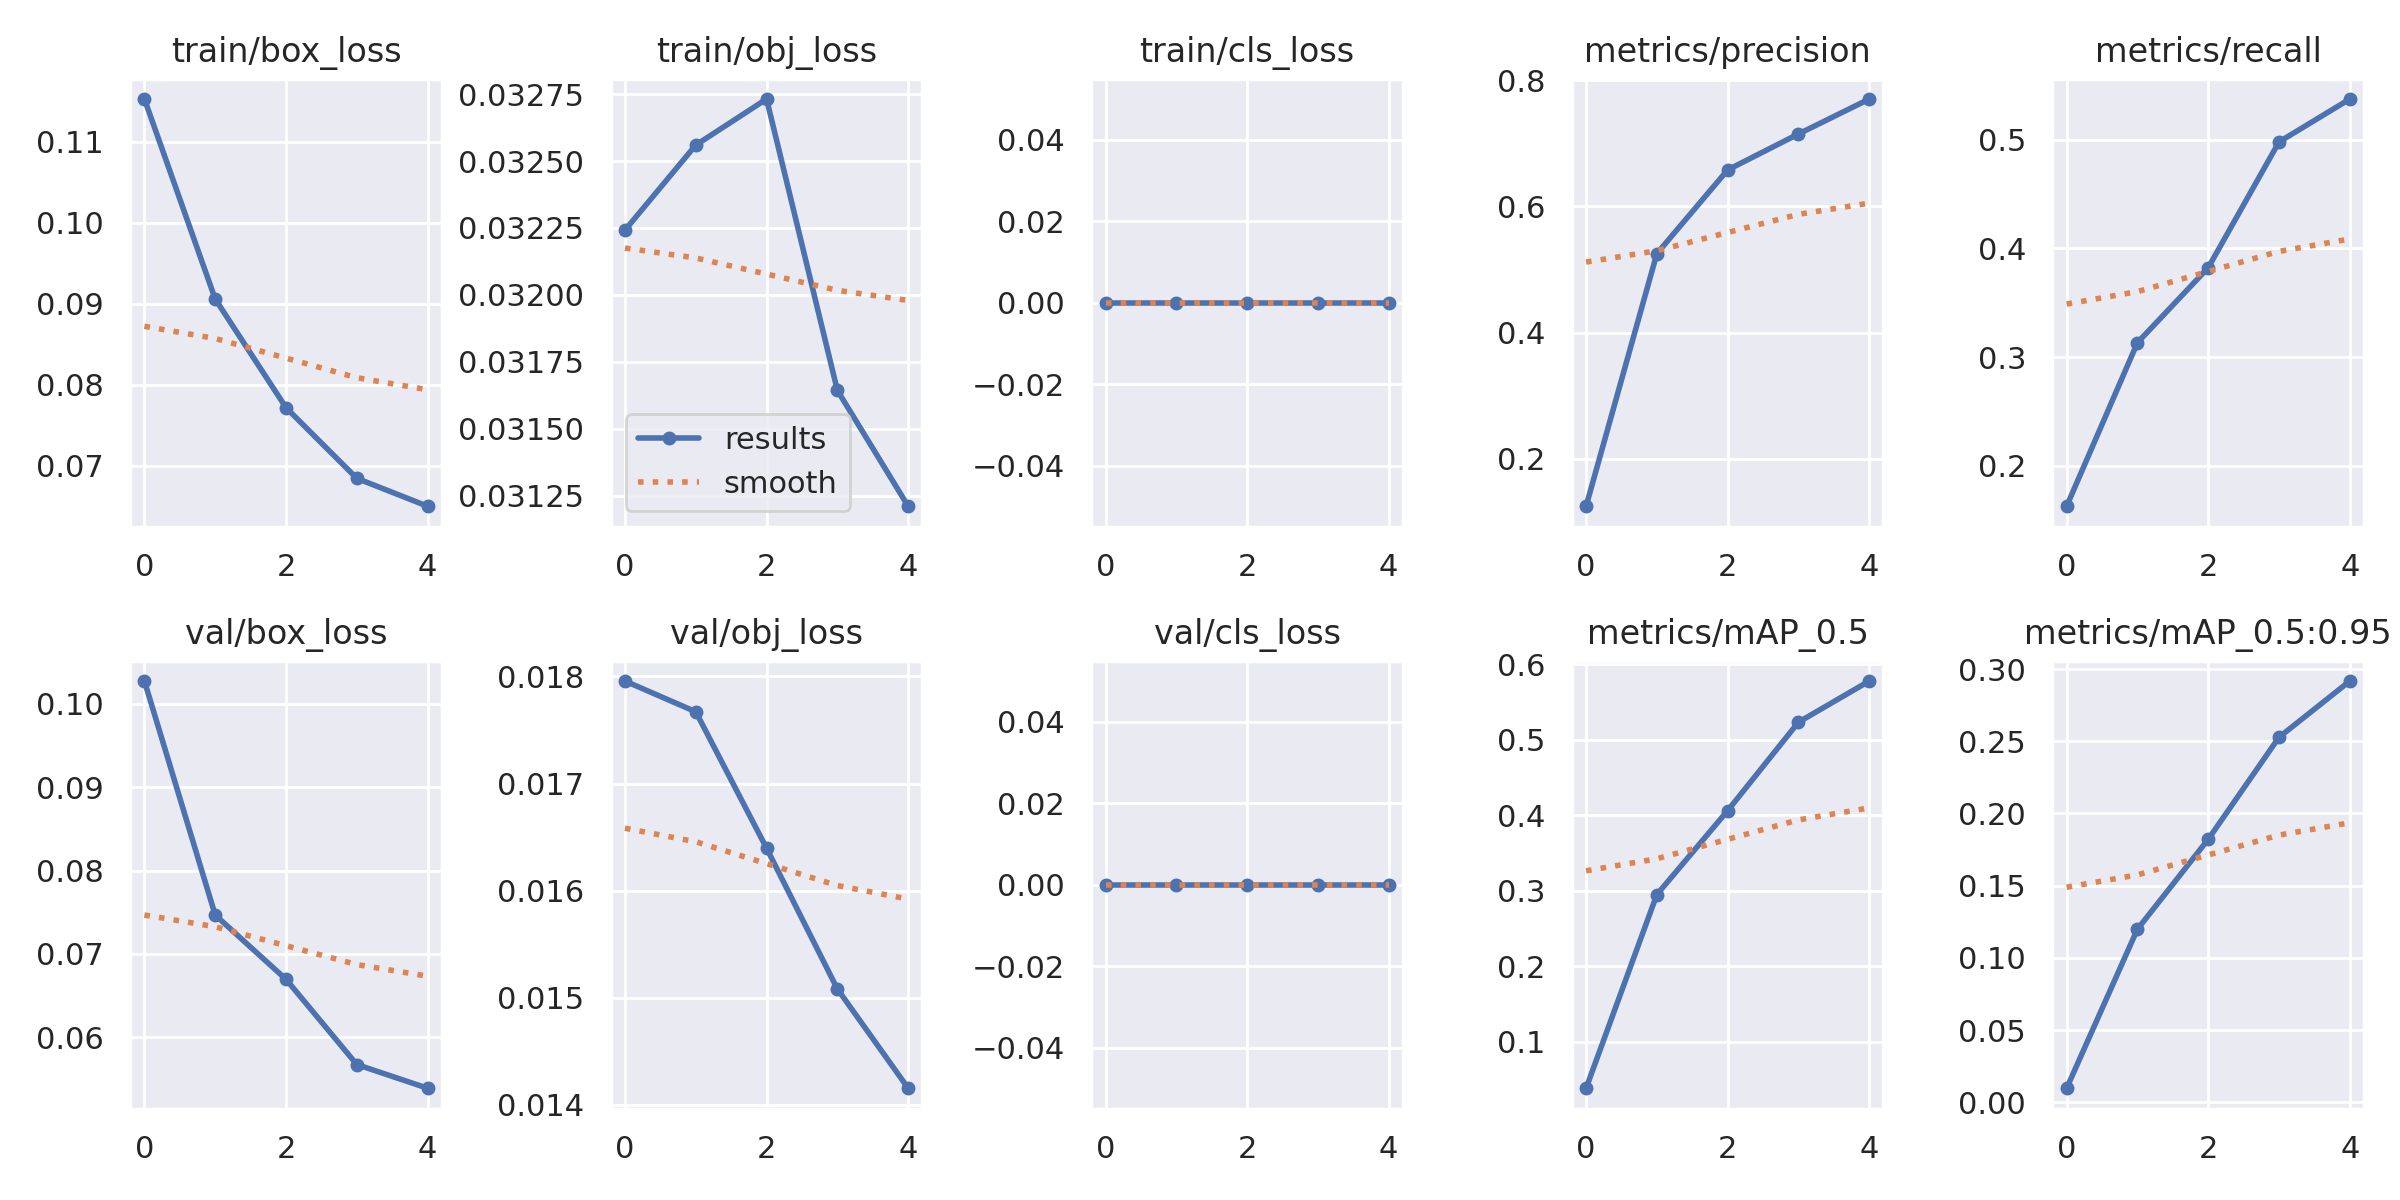

In [ ]:
from utils.plots import plot_results  # plot results.txt as results.png
Image(filename='/content/yolov5/runs/train/yolov5l_results2/results.png', width=1000)  # view results.png

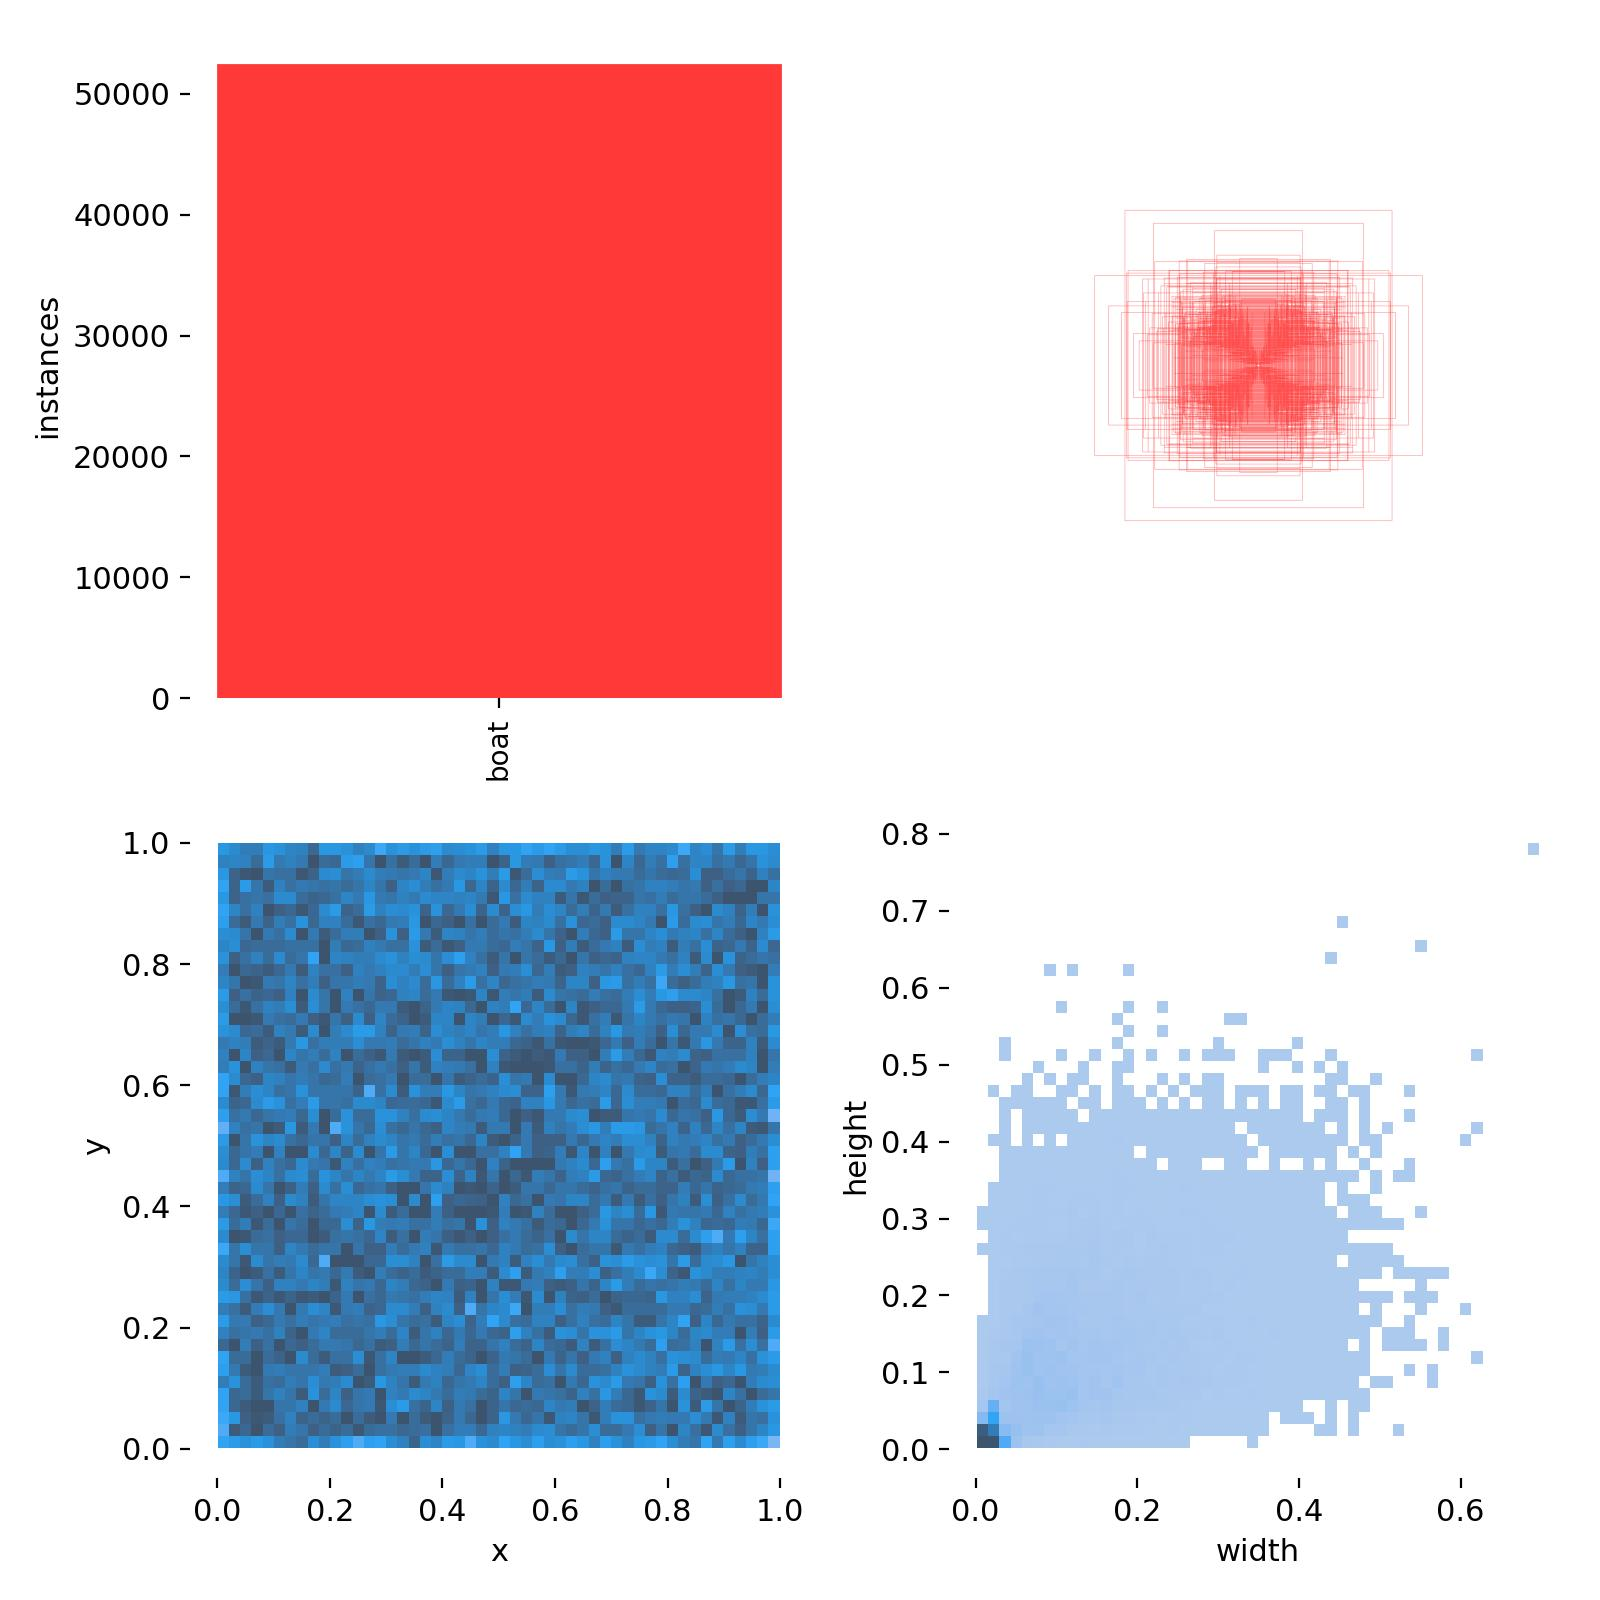

In [ ]:
Image(filename='/content/yolov5/runs/train/yolov5l_results2/labels.jpg', width=900)

GROUND TRUTH AUGMENTED TRAINING DATA:


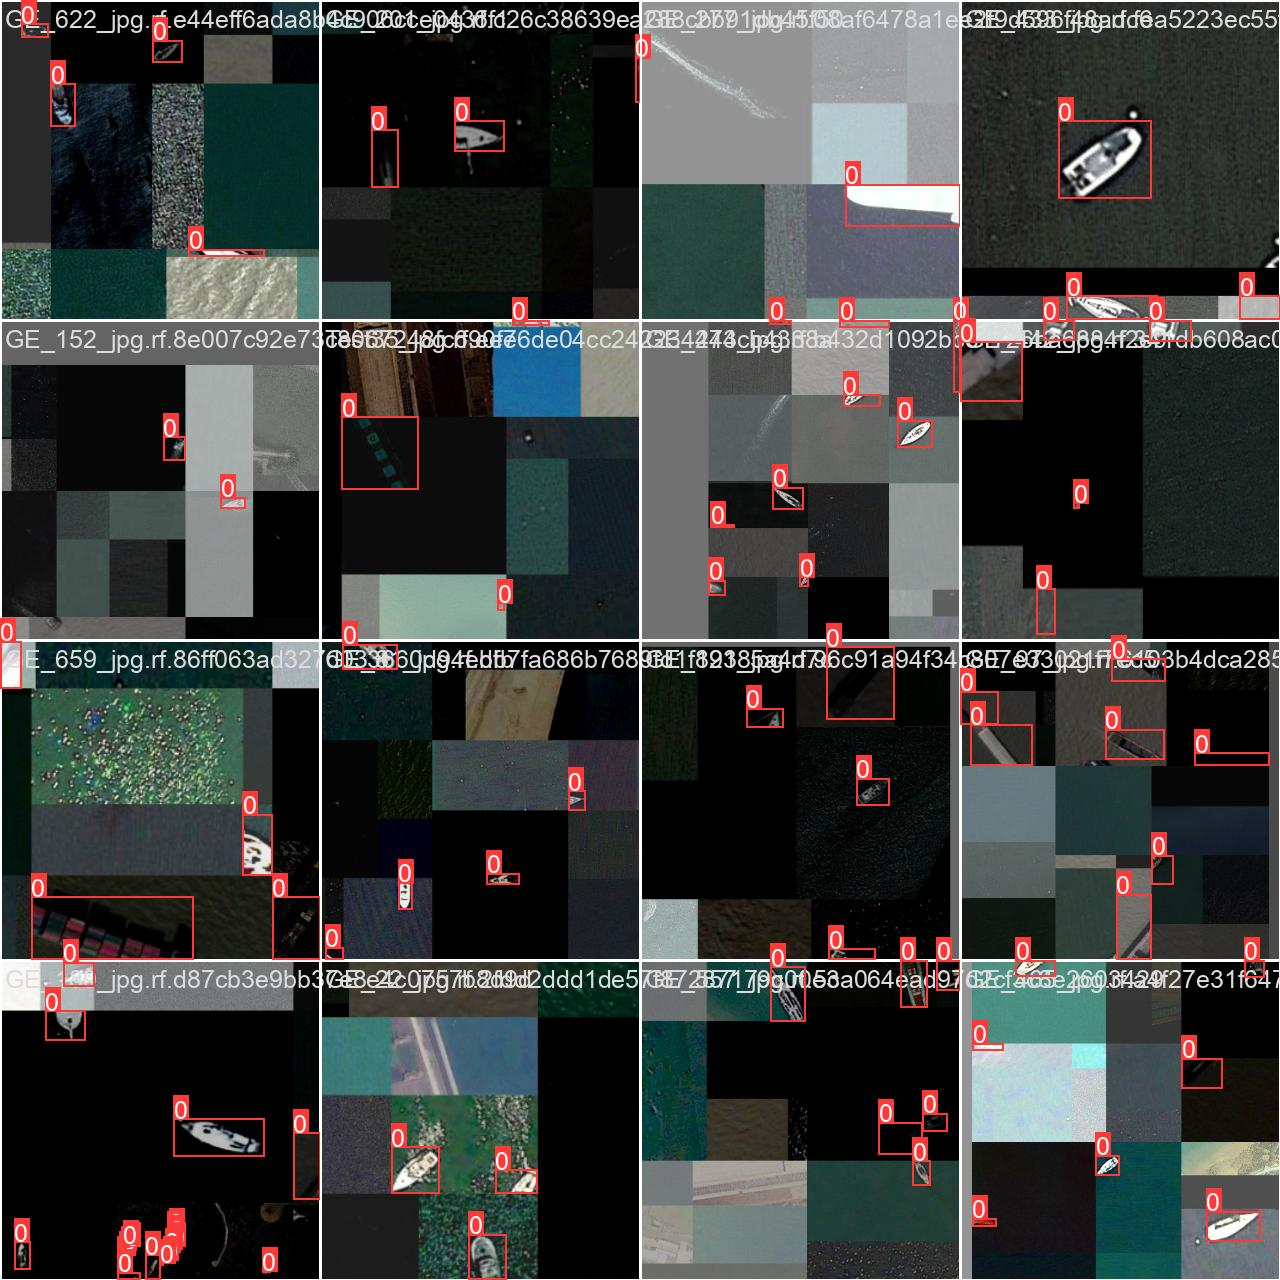

In [ ]:
# print out an augmented training example
print("GROUND TRUTH AUGMENTED TRAINING DATA:")
Image(filename='/content/yolov5/runs/train/yolov5l_results2/train_batch0.jpg', width=900)

In [ ]:
# trained weights are saved by default in our weights folder
%ls runs/

detect/  train/


In [ ]:
%ls runs/train/yolov5l_results2/weights

best.pt  last.pt


In [ ]:
%cd /content/yolov5/
!python detect.py --weights /content/yolov5/runs/train/yolov5l_results2/weights/best.pt --img 416 --conf 0.4 --source /content/yolov5/boat-detection-1/test/images



/content/yolov5
detect: weights=['/content/yolov5/runs/train/yolov5l_results2/weights/best.pt'], source=/content/yolov5/boat-detection-1/test/images, data=data/coco128.yaml, imgsz=[416, 416], conf_thres=0.4, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-389-ge62a31b6 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)

Fusing layers... 
custom_YOLOv5l summary: 182 layers, 7246518 parameters, 0 gradients
WARNING ⚠️ NMS time limit 0.550s exceeded
image 1/36 /content/yolov5/boat-detection-1/test/images/GE_10_jpg.rf.a85c0fc3c5bcf46f3d22e7ea86c752db.jpg: 416x416 1 boat, 8.8ms
image 2/36 /content/yolov5/boat-detection-1/test/images/GE_112_jpg.rf.f84524fa

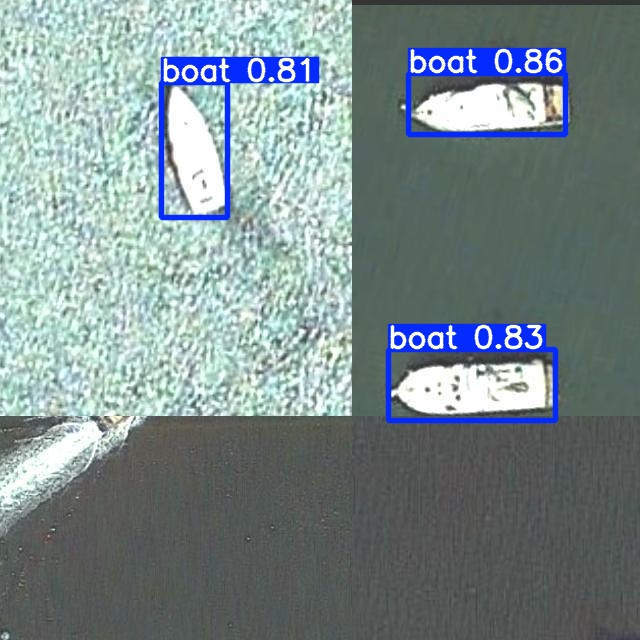

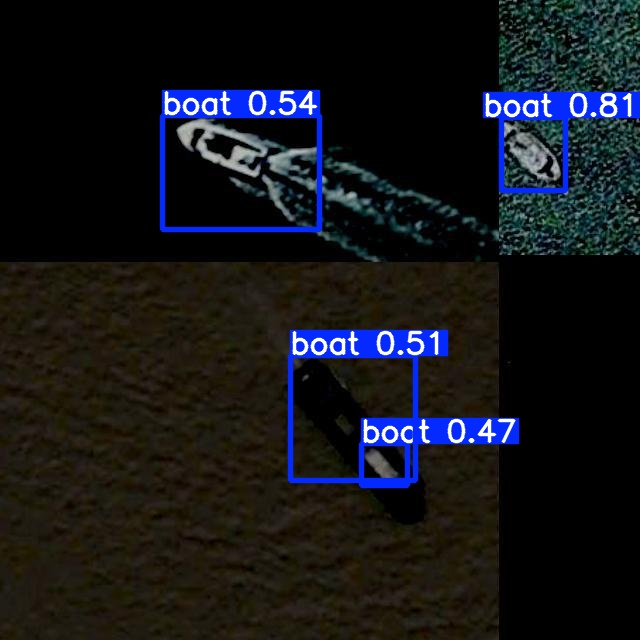

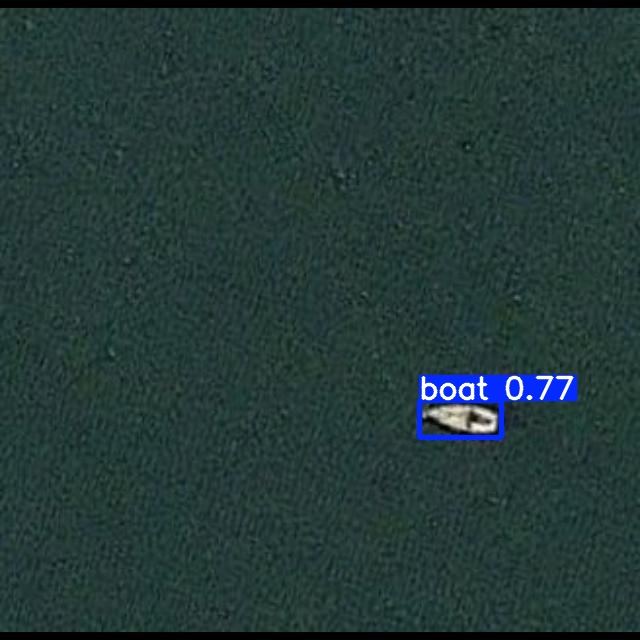

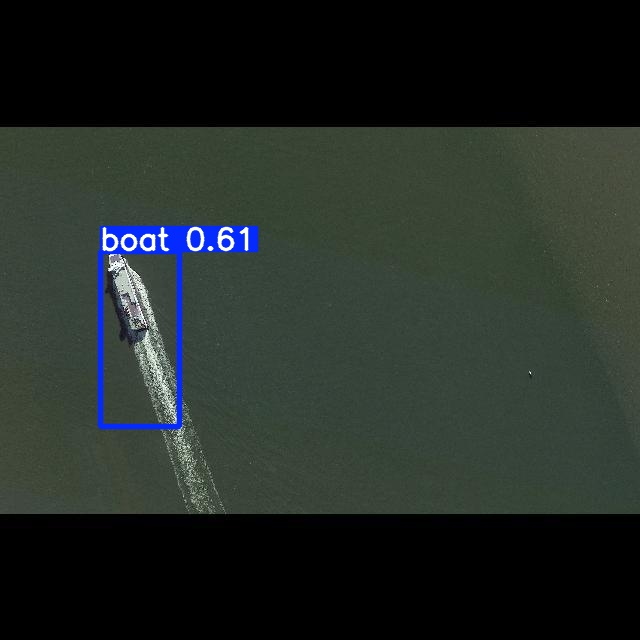

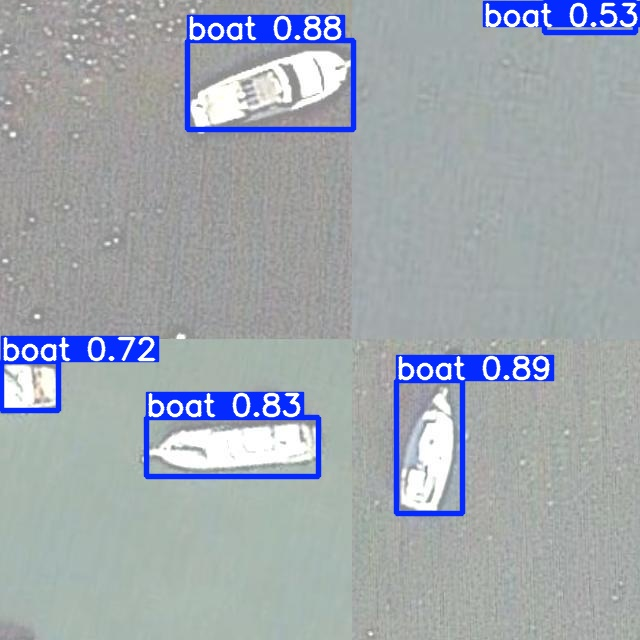

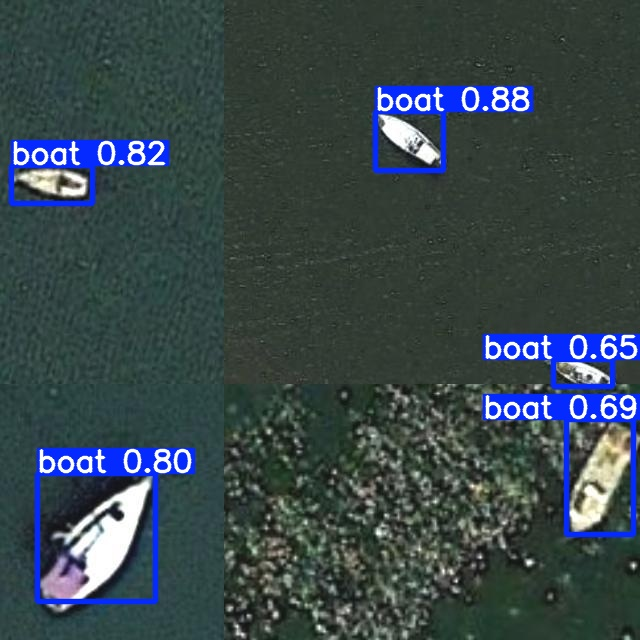

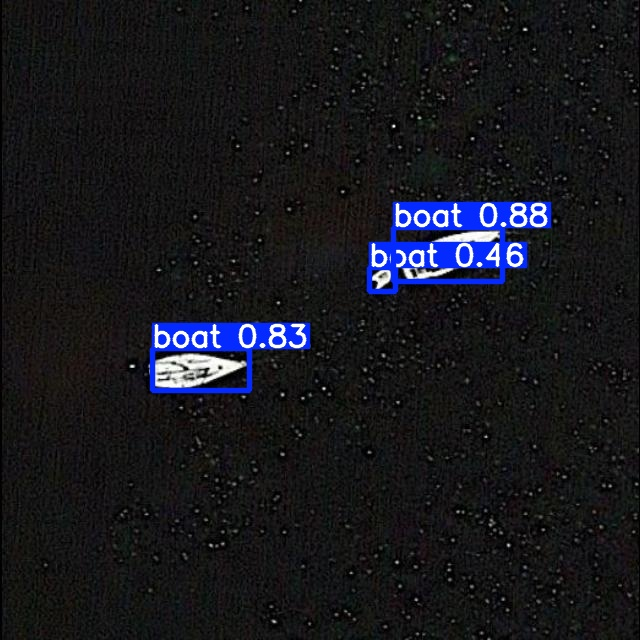

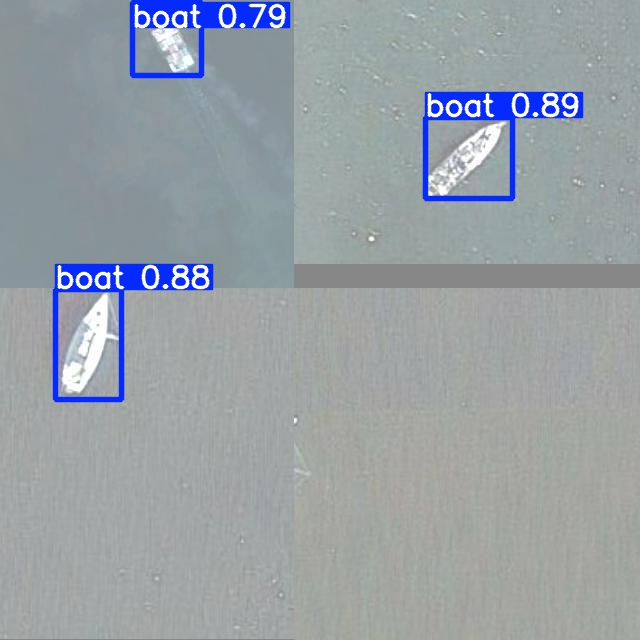

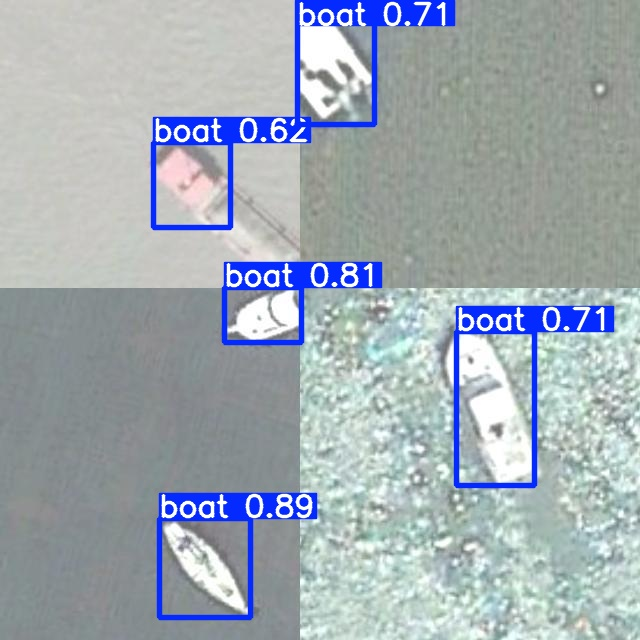

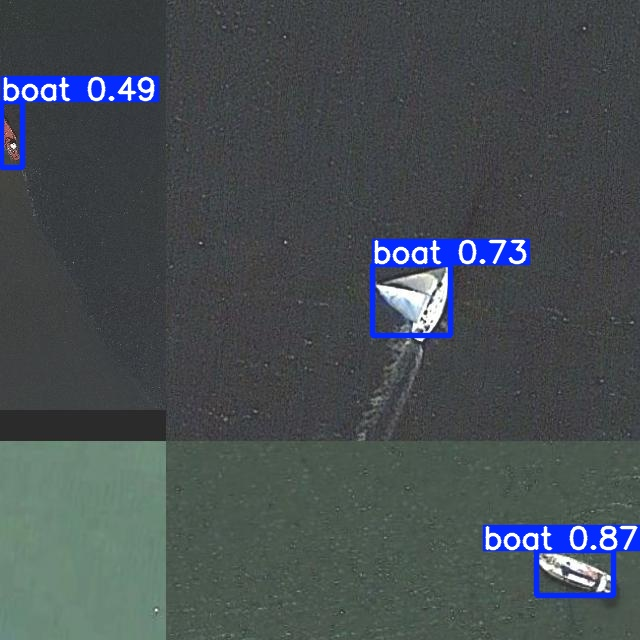

In [ ]:
import glob
from IPython.display import Image, display

# Path to your results folder
result_path = '/content/yolov5/runs/detect/exp3/'

# Display only .jpg images (adjust the number [:10] to display more or fewer images)
for imageName in glob.glob(result_path + '*.jpg')[:10]:  # Only for .jpg files
    display(Image(filename=imageName))


In [ ]:
from google.colab import files
uploaded = files.upload()  # This will allow you to upload a video file


Saving SampleInputForProject.mp4 to SampleInputForProject.mp4


In [ ]:
# Create a directory for videos (optional)
!mkdir /content/yolov5/videos

# Move the uploaded video to that directory (change "your_video.mp4" to the actual filename)
!mv SampleInputForProject.mp4 /content/yolov5/videos/


In [ ]:
!python /content/yolov5/detect.py --weights /content/yolov5/runs/train/yolov5l_results2/weights/best.pt --source /content/yolov5/videos/SampleInputForProject.mp4 --img 416 --conf 0.4


detect: weights=['/content/yolov5/runs/train/yolov5l_results2/weights/best.pt'], source=/content/yolov5/videos/SampleInputForProject.mp4, data=data/coco128.yaml, imgsz=[416, 416], conf_thres=0.4, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-389-ge62a31b6 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)

Fusing layers... 
custom_YOLOv5l summary: 182 layers, 7246518 parameters, 0 gradients
WARNING ⚠️ NMS time limit 0.550s exceeded
video 1/1 (1/301) /content/yolov5/videos/SampleInputForProject.mp4: 256x416 2 boats, 53.9ms
video 1/1 (2/301) /content/yolov5/videos/SampleInputForProject.mp4: 256x416 2 boats, 8.9ms
video 1/1 (3/301) /content/yolov5/vi

In [ ]:
from IPython.display import Video

# Display the video in the notebook
Video('/content/yolov5/runs/detect/exp4/SampleInputForProject.mp4')
